----- Comparison for PEHE (Variant 1) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k  9.098 +/- 2.718 11.006 +/- 3.318  9.170 +/- 2.778
 0.5k  9.311 +/- 2.849 10.635 +/- 2.687  9.303 +/- 2.933
0.25k  9.388 +/- 2.837 10.884 +/- 3.023  9.289 +/- 2.596
 0.1k  9.628 +/- 2.908 10.679 +/- 2.756  9.671 +/- 3.163
0.05k 10.345 +/- 2.847 10.950 +/- 2.748 10.711 +/- 3.012




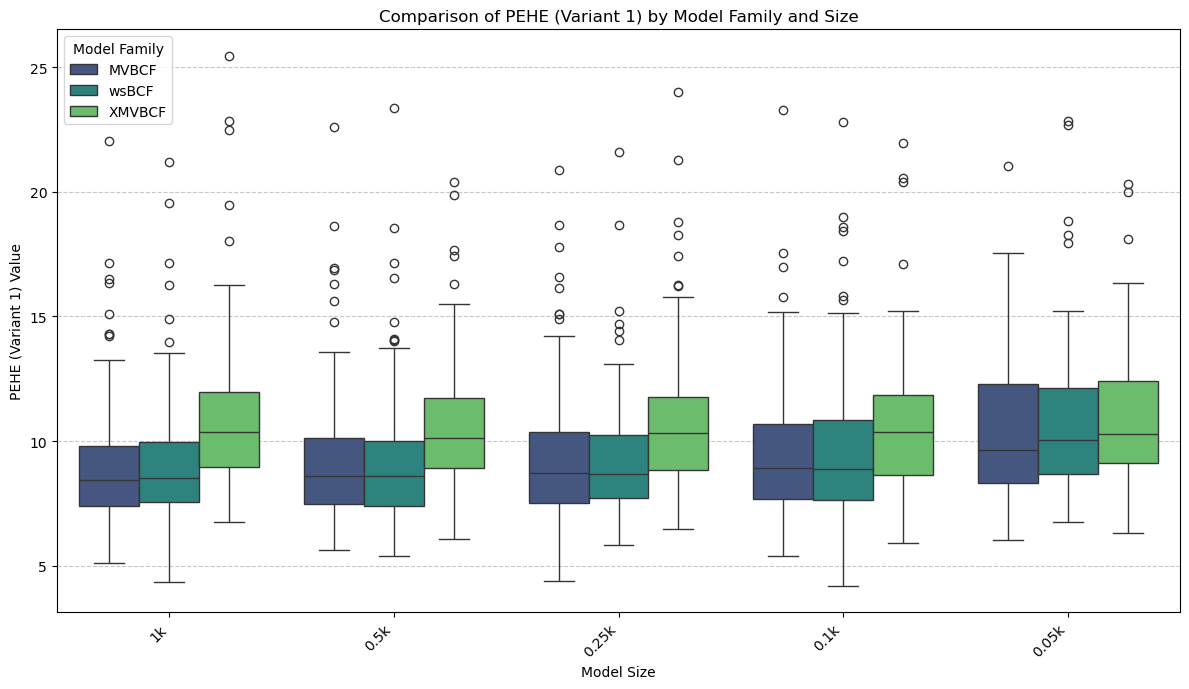

----- Comparison for PEHE (Variant 2) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k  9.443 +/- 2.655 10.703 +/- 2.378  9.346 +/- 2.784
 0.5k  9.438 +/- 2.753 10.680 +/- 2.578  9.443 +/- 2.585
0.25k  9.766 +/- 2.971 10.747 +/- 2.730  9.654 +/- 2.634
 0.1k  9.885 +/- 2.468 10.346 +/- 2.326 10.054 +/- 2.942
0.05k 10.731 +/- 3.195 10.655 +/- 2.484 11.125 +/- 3.162




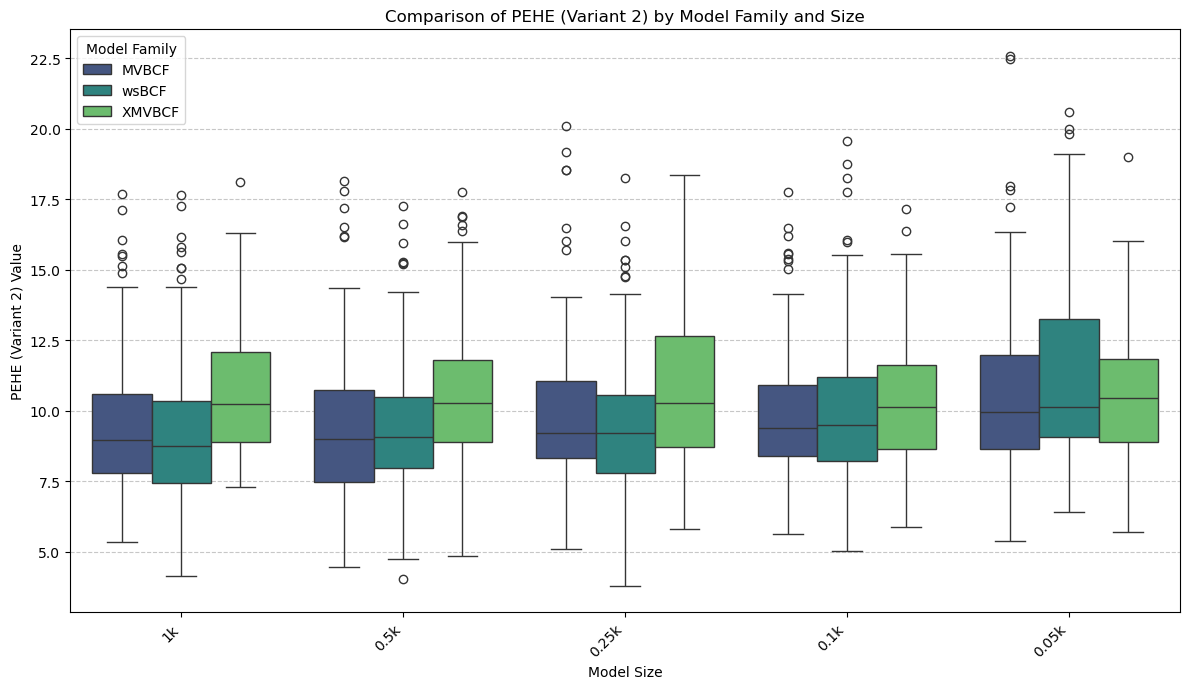

----- Comparison for Tau_95 (Variant 1) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 0.965 +/- 0.067 0.967 +/- 0.057 0.964 +/- 0.071
 0.5k 0.954 +/- 0.083 0.971 +/- 0.040 0.951 +/- 0.094
0.25k 0.939 +/- 0.092 0.970 +/- 0.047 0.947 +/- 0.079
 0.1k 0.899 +/- 0.109 0.968 +/- 0.049 0.903 +/- 0.125
0.05k 0.838 +/- 0.121 0.967 +/- 0.048 0.885 +/- 0.102




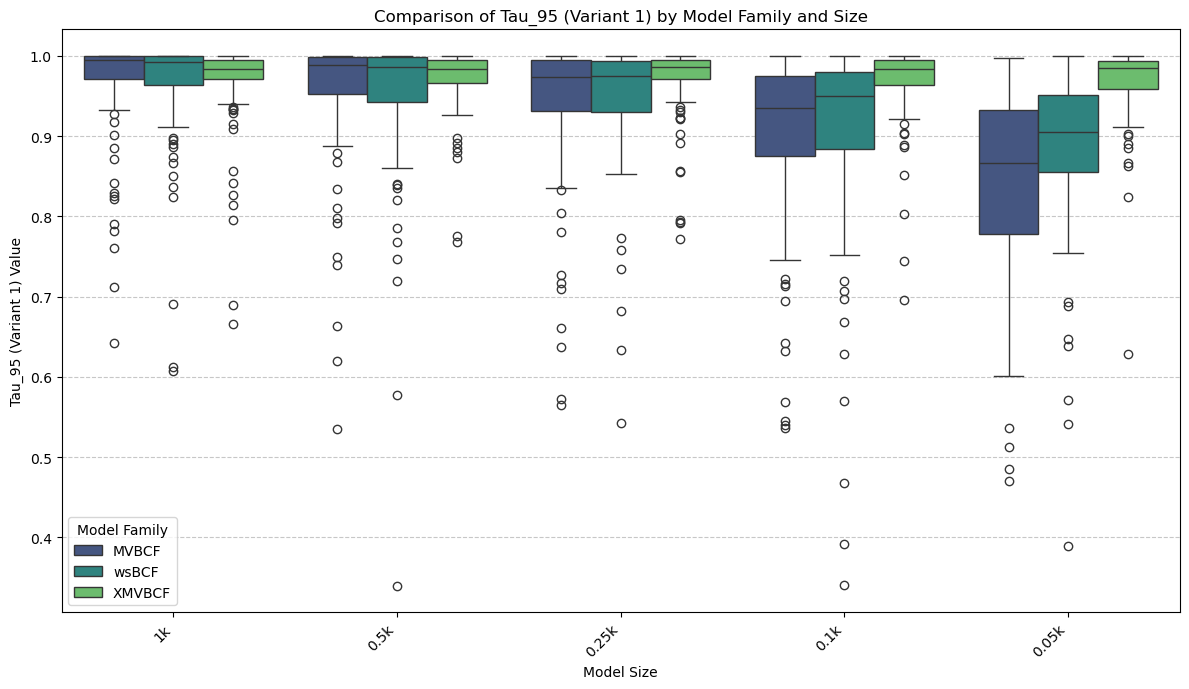

----- Comparison for Tau_95 (Variant 2) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 0.950 +/- 0.080 0.966 +/- 0.036 0.951 +/- 0.086
 0.5k 0.942 +/- 0.090 0.966 +/- 0.043 0.942 +/- 0.082
0.25k 0.921 +/- 0.113 0.966 +/- 0.043 0.927 +/- 0.089
 0.1k 0.889 +/- 0.100 0.972 +/- 0.035 0.882 +/- 0.122
0.05k 0.806 +/- 0.143 0.964 +/- 0.040 0.851 +/- 0.124




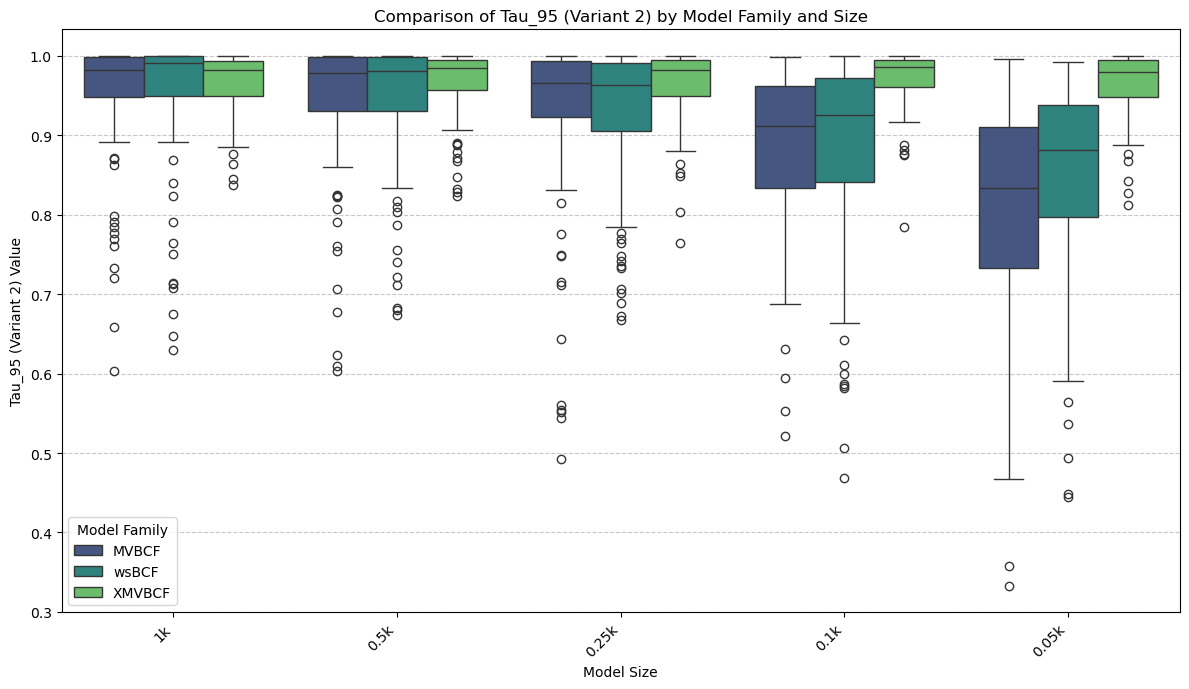

----- Comparison for Tau_95w (Variant 1) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 40.244 +/- 3.530 54.770 +/- 4.234 40.100 +/- 3.528
 0.5k 39.334 +/- 3.743 55.609 +/- 4.454 39.193 +/- 3.436
0.25k 38.182 +/- 3.644 55.215 +/- 4.606 38.581 +/- 3.428
 0.1k 34.921 +/- 3.962 55.384 +/- 4.513 35.698 +/- 3.804
0.05k 31.926 +/- 4.415 55.222 +/- 4.121 37.773 +/- 4.466




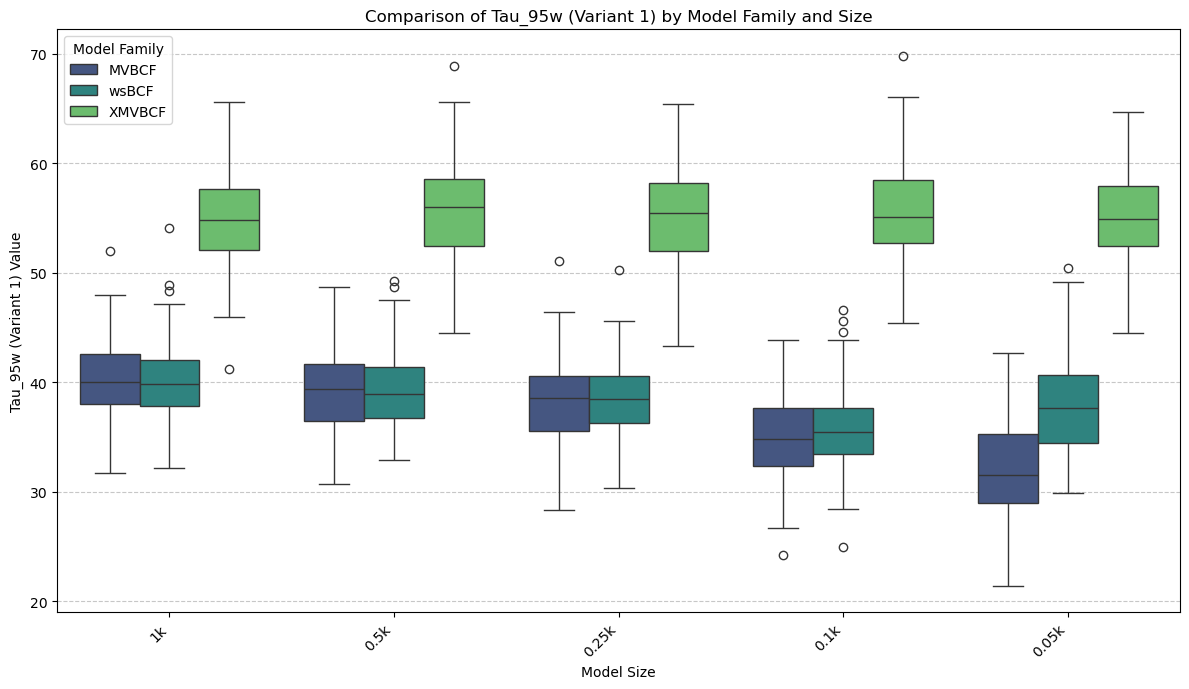

----- Comparison for Tau_95w (Variant 2) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 38.854 +/- 3.058 52.154 +/- 3.990 38.826 +/- 2.551
 0.5k 38.206 +/- 2.961 52.998 +/- 3.985 38.181 +/- 3.002
0.25k 36.626 +/- 2.836 52.802 +/- 4.174 37.134 +/- 3.028
 0.1k 34.260 +/- 3.527 53.084 +/- 4.163 34.598 +/- 3.416
0.05k 31.351 +/- 4.593 52.369 +/- 3.492 35.986 +/- 3.658




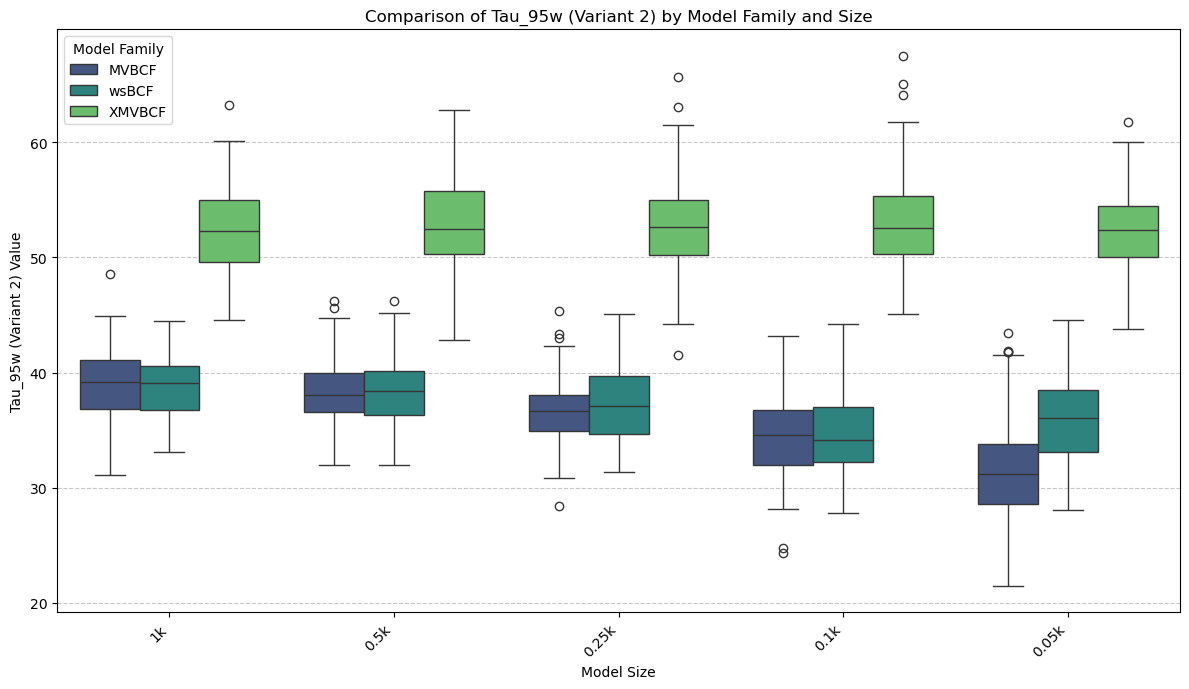

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    df_mvbcf = pd.read_csv("simulation_results_DGP1_original.csv")
    df_wsmvbcf = pd.read_csv("simulation_results_DGP1.csv")
    # Add wsBCF model, as per request, using the same CSV as XMVBCF.
    # Note: If wsBCF is truly a distinct model using this file, its column names
    # (e.g., 'wsbcf_1k_pehe1') should ideally be different from XMVBCF's ('mvbcf_1k_pehe1').
    # However, following the prompt literally, we'll assume its relevant data
    # shares the 'mvbcf_' prefix in this file, leading to identical results with XMVBCF.
    df_xmvbcf = pd.read_csv("XMVBCF_simulation_results_DGP1.csv") 
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
df_mvbcf['model_family'] = 'MVBCF'
df_xmvbcf['model_family'] = 'XMVBCF'
df_wsmvbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine all DataFrames
df_combined = pd.concat([df_mvbcf, df_xmvbcf, df_wsmvbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get MVBCF results
        mvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if mvbcf_col in df_mvbcf.columns:
            mean_mvbcf = df_mvbcf[mvbcf_col].mean()
            std_mvbcf = df_mvbcf[mvbcf_col].std()
            row_data["MVBCF"] = f"{mean_mvbcf:.3f} +/- {std_mvbcf:.3f}"
        else:
            row_data["MVBCF"] = "N/A"

        # Get XMVBCF results
        # XMVBCF uses columns also prefixed 'mvbcf_' in its specific file.
        xmvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if xmvbcf_col in df_xmvbcf.columns:
            mean_xmvbcf = df_xmvbcf[xmvbcf_col].mean()
            std_xmvbcf = df_xmvbcf[xmvbcf_col].std()
            row_data["XMVBCF"] = f"{mean_xmvbcf:.3f} +/- {std_xmvbcf:.3f}"
        else:
            row_data["XMVBCF"] = "N/A"
            
        # Get wsBCF results
        # As per request, wsBCF uses the same CSV file as XMVBCF.
        # Assuming its relevant columns are also prefixed 'mvbcf_'.
        wsbcf_col = f"mvbcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsmvbcf.columns:
            mean_wsbcf = df_wsmvbcf[wsbcf_col].mean()
            std_wsbcf = df_wsmvbcf[wsbcf_col].std()
            row_data["wsMVBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsMVBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting
    plot_cols_prefix = "mvbcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    # Rename columns for melting: remove "mvbcf_" and the specific metric suffix
    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 36.746 +/- 5.146 37.064 +/- 5.414 36.804 +/- 5.045
 0.5k 36.884 +/- 5.134 37.049 +/- 5.295 36.787 +/- 5.138
0.25k 36.911 +/- 5.017 37.145 +/- 5.452 36.644 +/- 5.019
 0.1k 36.498 +/- 5.517 37.321 +/- 5.319 36.657 +/- 5.316
0.05k 38.516 +/- 5.507 37.001 +/- 5.333 38.012 +/- 5.250




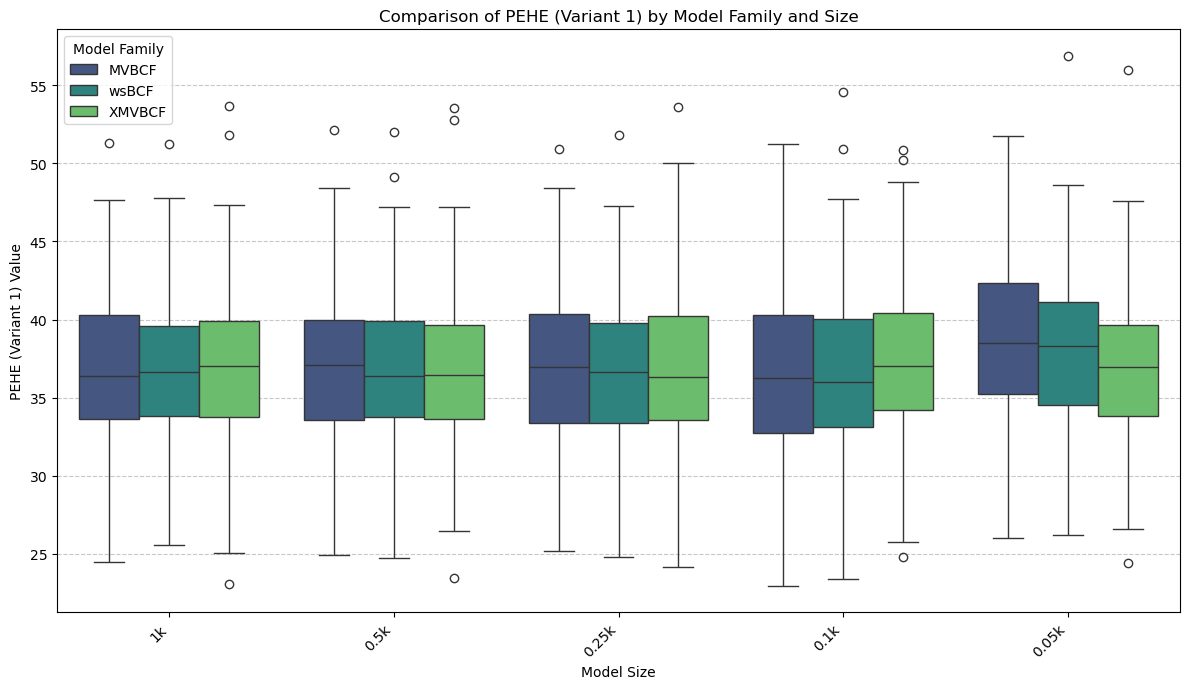

----- Comparison for PEHE (Variant 2) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 9.101 +/- 1.980 9.911 +/- 1.963 9.070 +/- 1.921
 0.5k 9.122 +/- 2.009 9.821 +/- 2.076 9.128 +/- 1.864
0.25k 9.214 +/- 2.087 9.832 +/- 2.050 9.214 +/- 1.880
 0.1k 9.464 +/- 2.065 9.939 +/- 1.930 9.447 +/- 1.950
0.05k 9.577 +/- 2.098 9.792 +/- 1.919 9.720 +/- 1.819




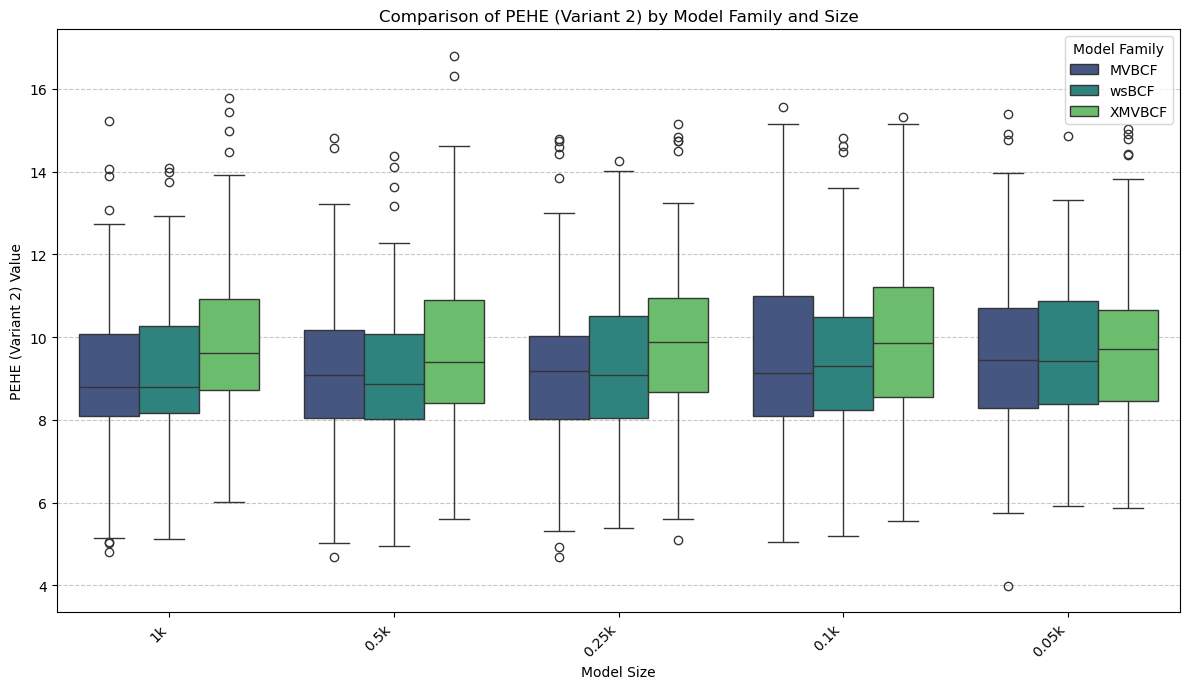

----- Comparison for Tau_95 (Variant 1) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 0.066 +/- 0.087 0.300 +/- 0.137 0.065 +/- 0.086
 0.5k 0.063 +/- 0.082 0.299 +/- 0.137 0.066 +/- 0.088
0.25k 0.060 +/- 0.077 0.294 +/- 0.131 0.062 +/- 0.084
 0.1k 0.061 +/- 0.083 0.300 +/- 0.129 0.051 +/- 0.068
0.05k 0.040 +/- 0.063 0.323 +/- 0.134 0.071 +/- 0.077




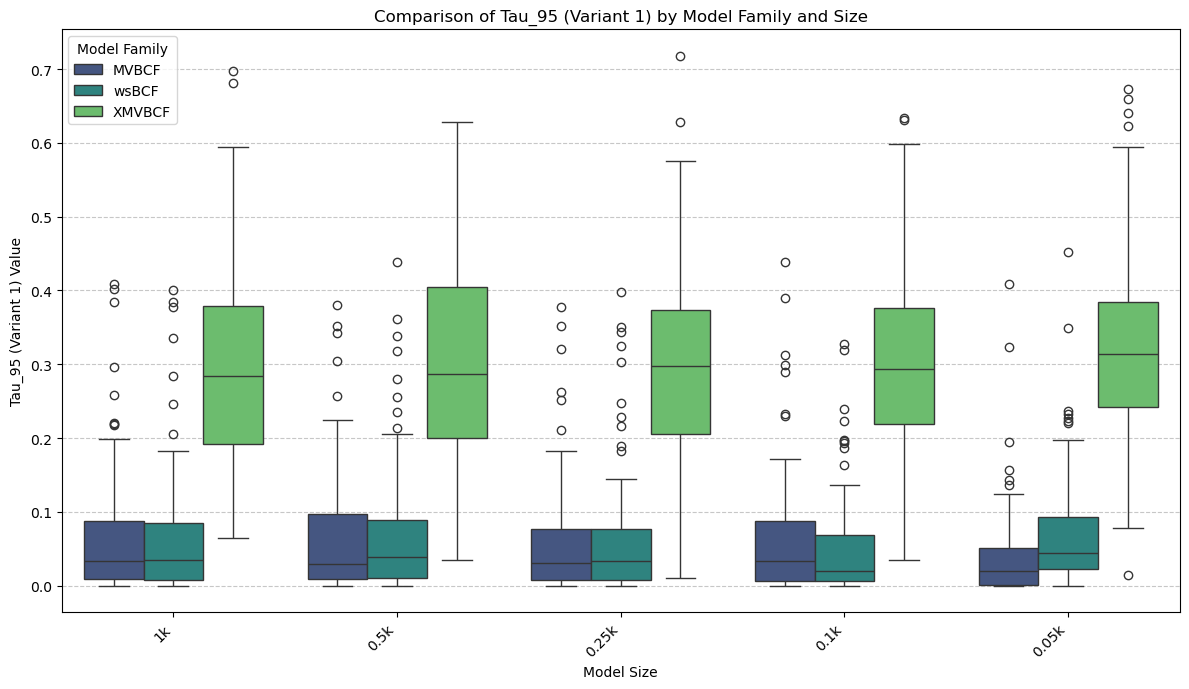

----- Comparison for Tau_95 (Variant 2) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 0.926 +/- 0.080 0.952 +/- 0.043 0.929 +/- 0.073
 0.5k 0.913 +/- 0.083 0.953 +/- 0.045 0.918 +/- 0.080
0.25k 0.895 +/- 0.096 0.953 +/- 0.042 0.901 +/- 0.088
 0.1k 0.851 +/- 0.099 0.952 +/- 0.041 0.852 +/- 0.101
0.05k 0.805 +/- 0.126 0.961 +/- 0.035 0.847 +/- 0.089




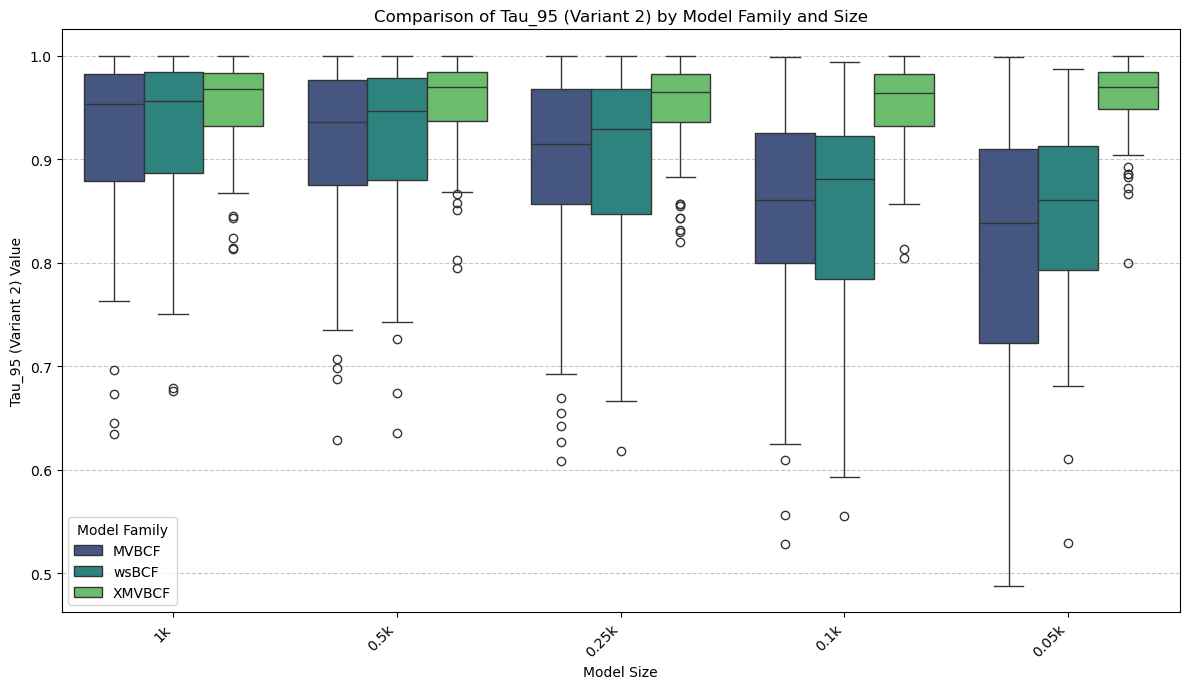

----- Comparison for Tau_95w (Variant 1) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 39.222 +/- 3.068 54.709 +/- 4.162 39.484 +/- 3.124
 0.5k 38.433 +/- 3.133 54.565 +/- 4.170 38.904 +/- 3.296
0.25k 37.759 +/- 3.436 54.809 +/- 3.998 37.597 +/- 3.577
 0.1k 34.887 +/- 3.635 55.158 +/- 4.556 34.780 +/- 3.559
0.05k 31.294 +/- 4.239 55.978 +/- 3.805 36.953 +/- 4.240




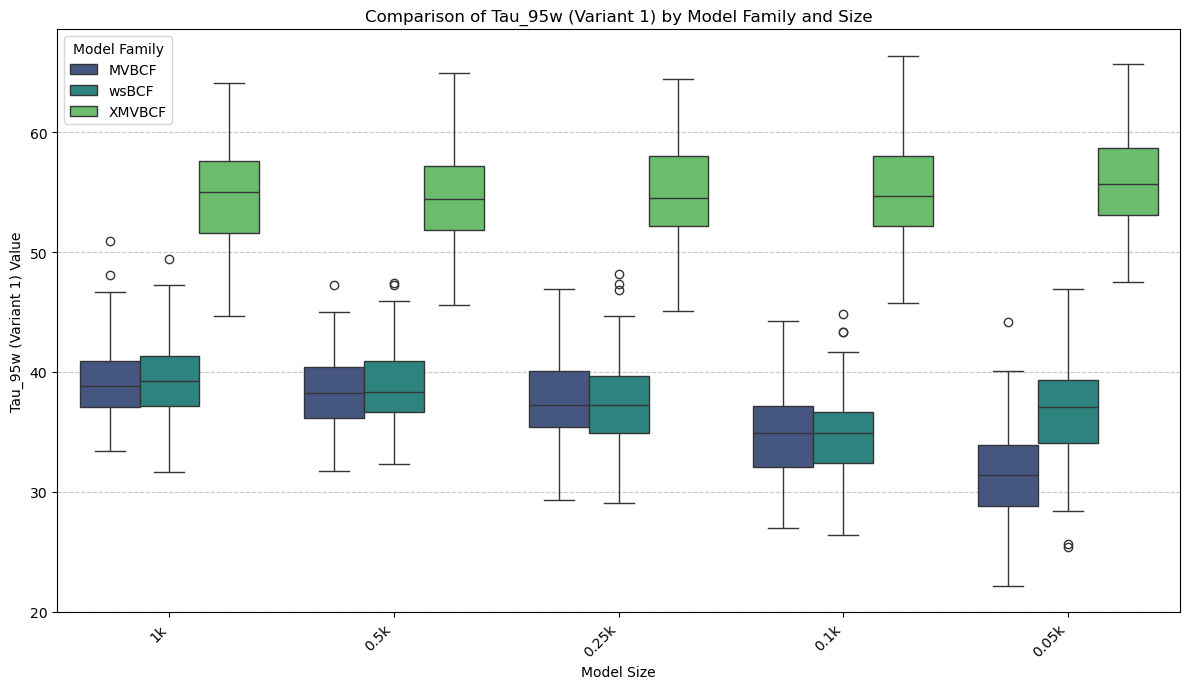

----- Comparison for Tau_95w (Variant 2) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 33.203 +/- 2.523 43.756 +/- 3.278 33.156 +/- 2.451
 0.5k 32.416 +/- 2.474 43.813 +/- 3.083 32.692 +/- 2.630
0.25k 31.450 +/- 2.810 43.622 +/- 3.092 31.734 +/- 2.625
 0.1k 29.454 +/- 2.761 43.518 +/- 3.237 29.567 +/- 2.946
0.05k 27.410 +/- 3.186 44.645 +/- 2.981 30.312 +/- 3.345




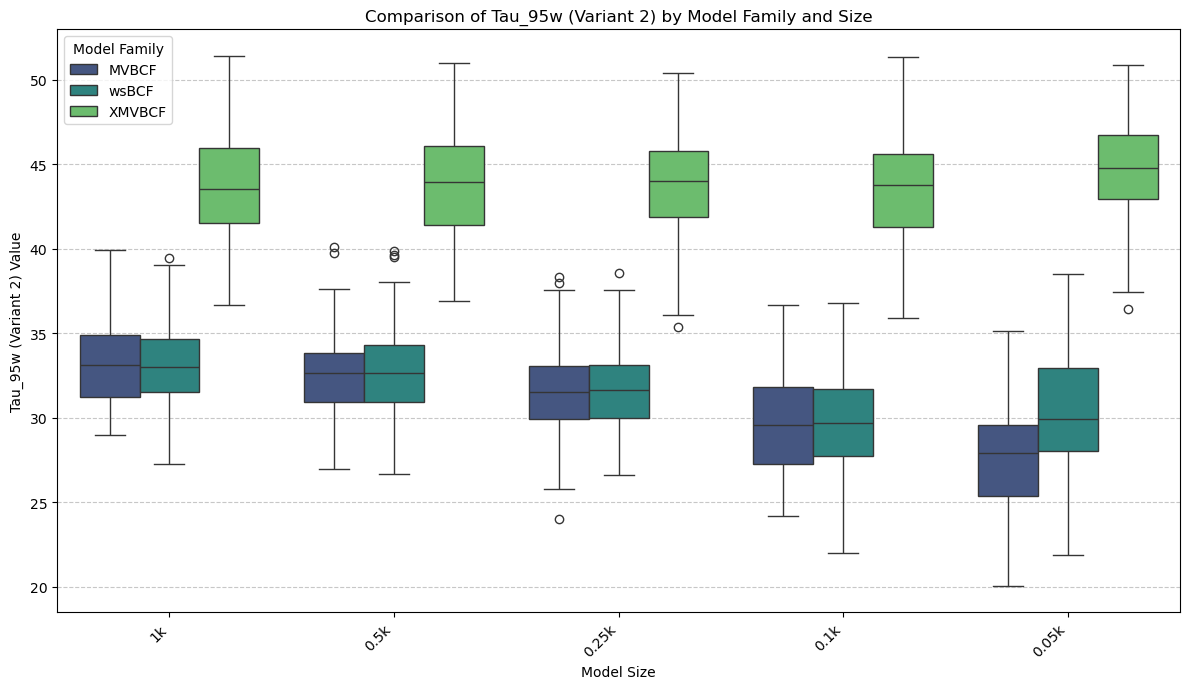

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    df_mvbcf = pd.read_csv("simulation_results_DGP2_original.csv")
    df_wsmvbcf = pd.read_csv("simulation_results_DGP2.csv")
    # Add wsBCF model, as per request, using the same CSV as XMVBCF.
    # Note: If wsBCF is truly a distinct model using this file, its column names
    # (e.g., 'wsbcf_1k_pehe1') should ideally be different from XMVBCF's ('mvbcf_1k_pehe1').
    # However, following the prompt literally, we'll assume its relevant data
    # shares the 'mvbcf_' prefix in this file, leading to identical results with XMVBCF.
    df_xmvbcf = pd.read_csv("XMVBCF_simulation_results_DGP2.csv") 
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
df_mvbcf['model_family'] = 'MVBCF'
df_xmvbcf['model_family'] = 'XMVBCF'
df_wsmvbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine all DataFrames
df_combined = pd.concat([df_mvbcf, df_xmvbcf, df_wsmvbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get MVBCF results
        mvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if mvbcf_col in df_mvbcf.columns:
            mean_mvbcf = df_mvbcf[mvbcf_col].mean()
            std_mvbcf = df_mvbcf[mvbcf_col].std()
            row_data["MVBCF"] = f"{mean_mvbcf:.3f} +/- {std_mvbcf:.3f}"
        else:
            row_data["MVBCF"] = "N/A"

        # Get XMVBCF results
        # XMVBCF uses columns also prefixed 'mvbcf_' in its specific file.
        xmvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if xmvbcf_col in df_xmvbcf.columns:
            mean_xmvbcf = df_xmvbcf[xmvbcf_col].mean()
            std_xmvbcf = df_xmvbcf[xmvbcf_col].std()
            row_data["XMVBCF"] = f"{mean_xmvbcf:.3f} +/- {std_xmvbcf:.3f}"
        else:
            row_data["XMVBCF"] = "N/A"
            
        # Get wsBCF results
        # As per request, wsBCF uses the same CSV file as XMVBCF.
        # Assuming its relevant columns are also prefixed 'mvbcf_'.
        wsbcf_col = f"mvbcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsmvbcf.columns:
            mean_wsbcf = df_wsmvbcf[wsbcf_col].mean()
            std_wsbcf = df_wsmvbcf[wsbcf_col].std()
            row_data["wsMVBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsMVBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting
    plot_cols_prefix = "mvbcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    # Rename columns for melting: remove "mvbcf_" and the specific metric suffix
    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 10.014 +/- 2.803 11.998 +/- 2.930  9.885 +/- 2.769
 0.5k 10.161 +/- 2.803 11.969 +/- 2.715 10.152 +/- 2.759
0.25k 10.216 +/- 2.707 11.724 +/- 3.118 10.340 +/- 2.930
 0.1k 10.949 +/- 3.017 12.091 +/- 2.985 10.632 +/- 2.827
0.05k 11.480 +/- 3.552 11.997 +/- 2.806 11.831 +/- 3.045




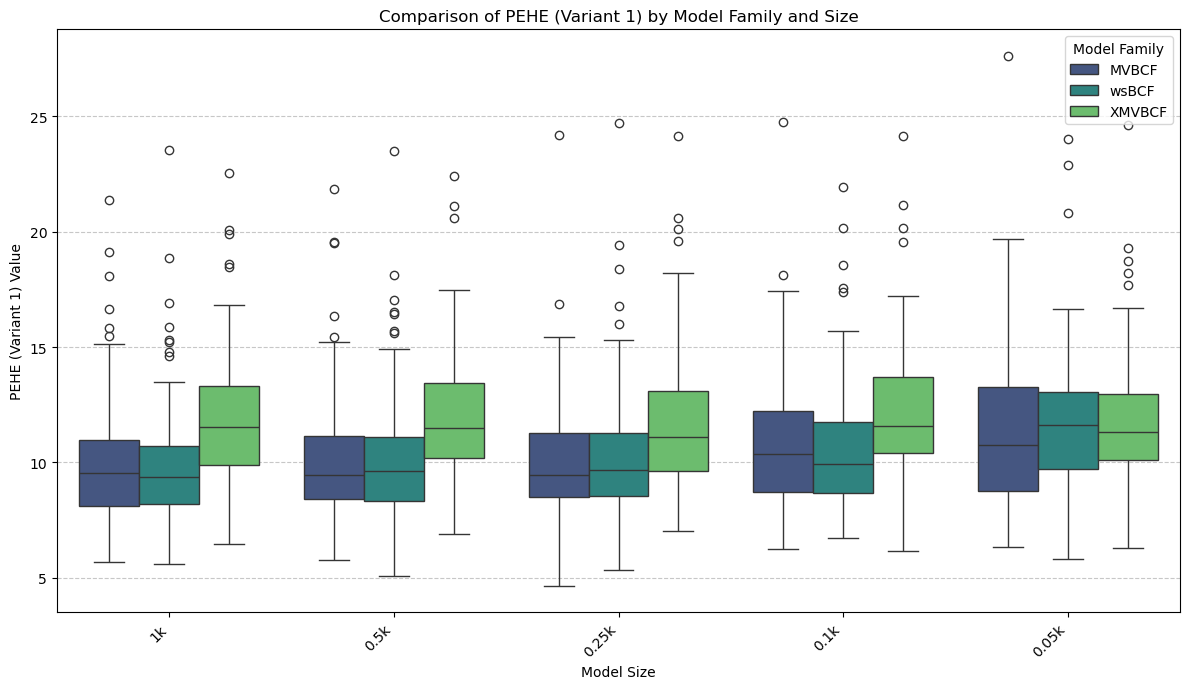

----- Comparison for PEHE (Variant 2) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k  9.739 +/- 2.562 10.760 +/- 2.647  9.775 +/- 2.575
 0.5k  9.730 +/- 2.628 10.670 +/- 2.460  9.692 +/- 2.779
0.25k  9.932 +/- 2.718 10.566 +/- 2.670  9.914 +/- 2.548
 0.1k 10.013 +/- 2.884 10.992 +/- 2.628 10.086 +/- 2.705
0.05k 10.901 +/- 3.184 10.854 +/- 2.726 11.159 +/- 2.770




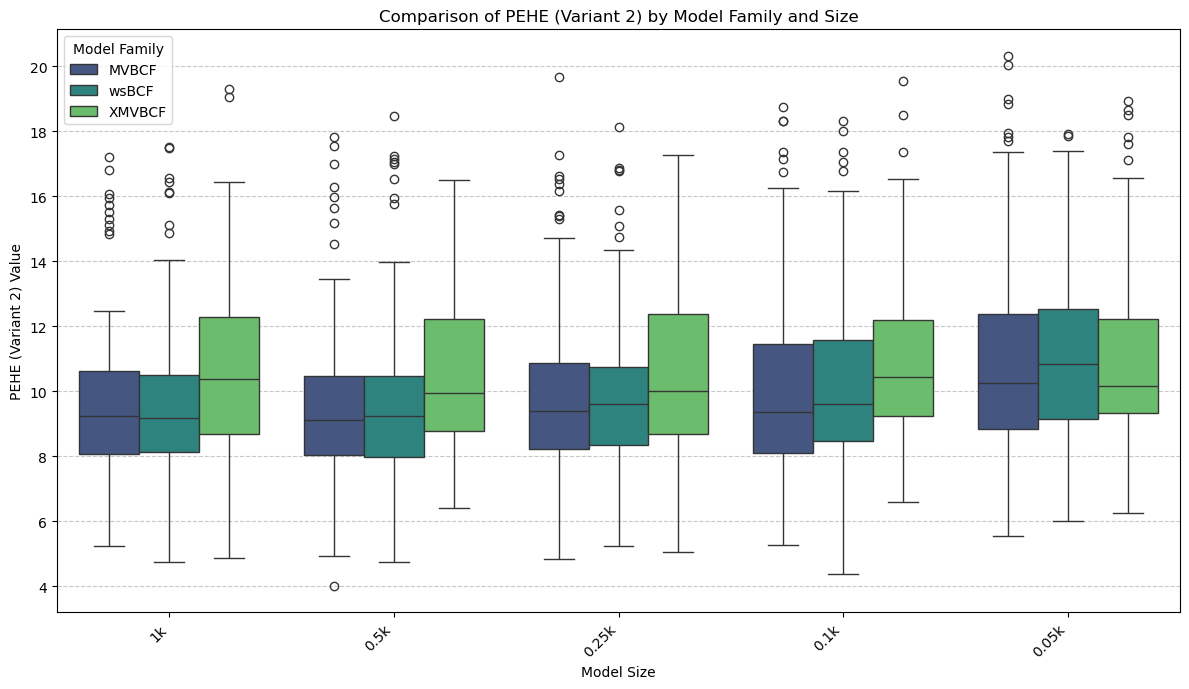

----- Comparison for Tau_95 (Variant 1) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 0.956 +/- 0.077 0.959 +/- 0.049 0.961 +/- 0.077
 0.5k 0.949 +/- 0.084 0.963 +/- 0.041 0.949 +/- 0.085
0.25k 0.937 +/- 0.078 0.964 +/- 0.053 0.929 +/- 0.094
 0.1k 0.877 +/- 0.110 0.956 +/- 0.050 0.894 +/- 0.100
0.05k 0.805 +/- 0.137 0.964 +/- 0.046 0.876 +/- 0.097




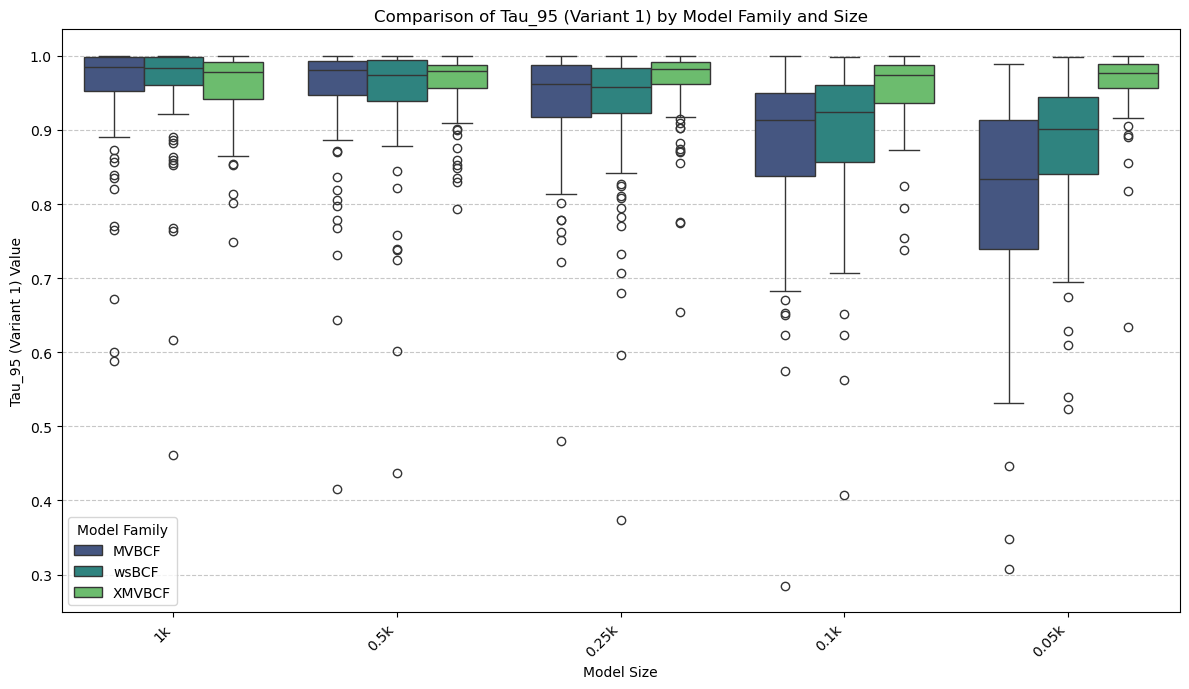

----- Comparison for Tau_95 (Variant 2) -----
Model           MVBCF          XMVBCF         wsMVBCF
   1k 0.944 +/- 0.084 0.963 +/- 0.044 0.944 +/- 0.086
 0.5k 0.936 +/- 0.090 0.968 +/- 0.032 0.937 +/- 0.097
0.25k 0.920 +/- 0.104 0.968 +/- 0.039 0.918 +/- 0.093
 0.1k 0.874 +/- 0.126 0.961 +/- 0.046 0.882 +/- 0.114
0.05k 0.798 +/- 0.153 0.963 +/- 0.050 0.855 +/- 0.107




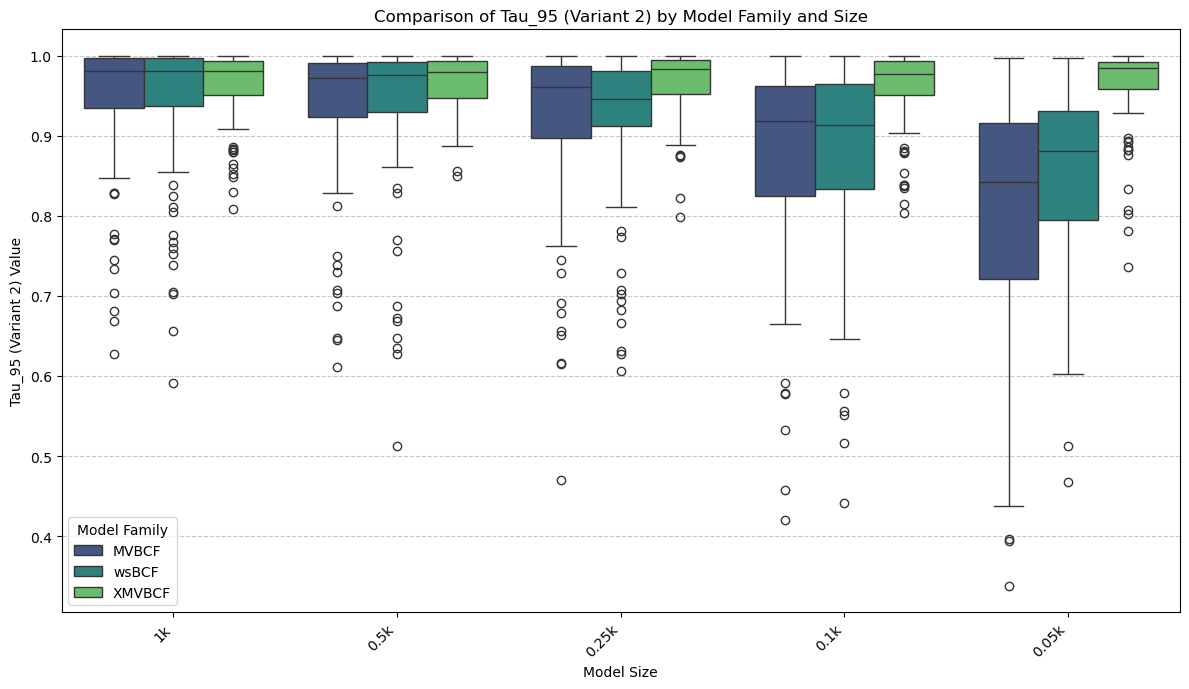

----- Comparison for Tau_95w (Variant 1) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 42.657 +/- 3.478 57.856 +/- 4.498 43.080 +/- 3.840
 0.5k 41.998 +/- 3.698 58.519 +/- 4.414 42.255 +/- 3.565
0.25k 40.468 +/- 4.034 58.514 +/- 4.801 40.891 +/- 3.755
 0.1k 37.104 +/- 4.420 57.509 +/- 4.531 37.904 +/- 3.516
0.05k 32.956 +/- 4.462 58.692 +/- 4.483 40.117 +/- 5.032




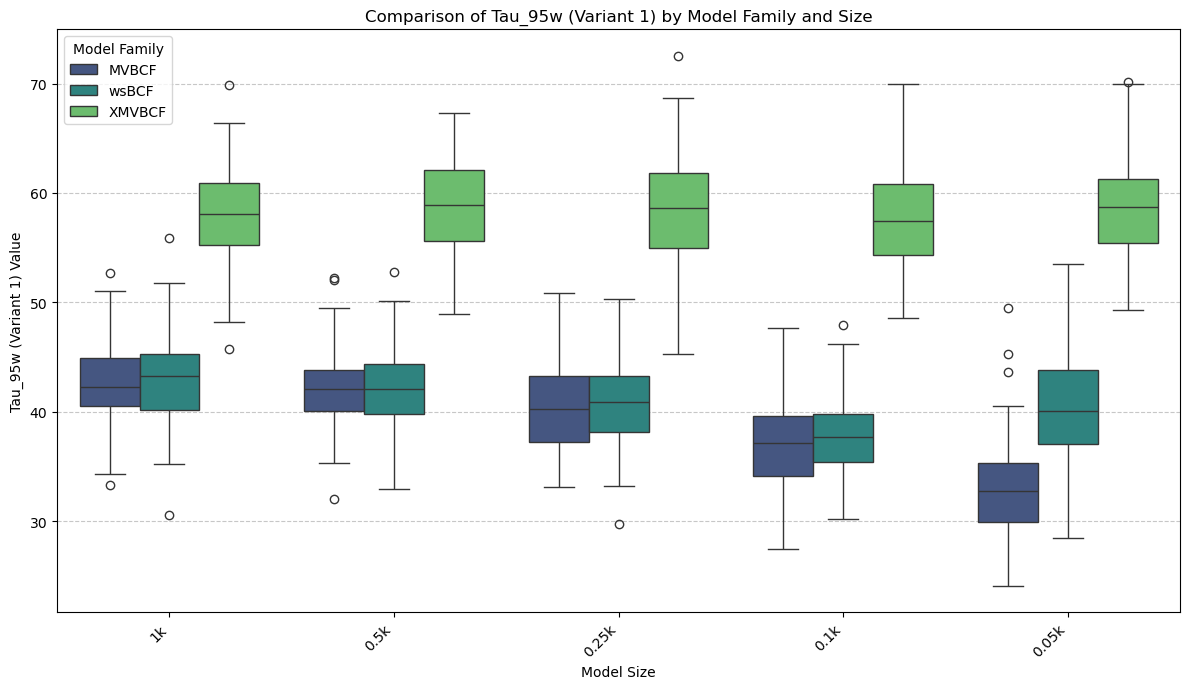

----- Comparison for Tau_95w (Variant 2) -----
Model            MVBCF           XMVBCF          wsMVBCF
   1k 38.800 +/- 3.172 51.723 +/- 3.887 38.864 +/- 2.939
 0.5k 38.059 +/- 2.696 52.581 +/- 4.149 38.183 +/- 2.832
0.25k 37.051 +/- 3.403 52.717 +/- 3.891 37.167 +/- 2.791
 0.1k 34.319 +/- 4.268 52.165 +/- 4.217 35.100 +/- 3.537
0.05k 30.879 +/- 3.789 52.053 +/- 3.711 36.660 +/- 4.454




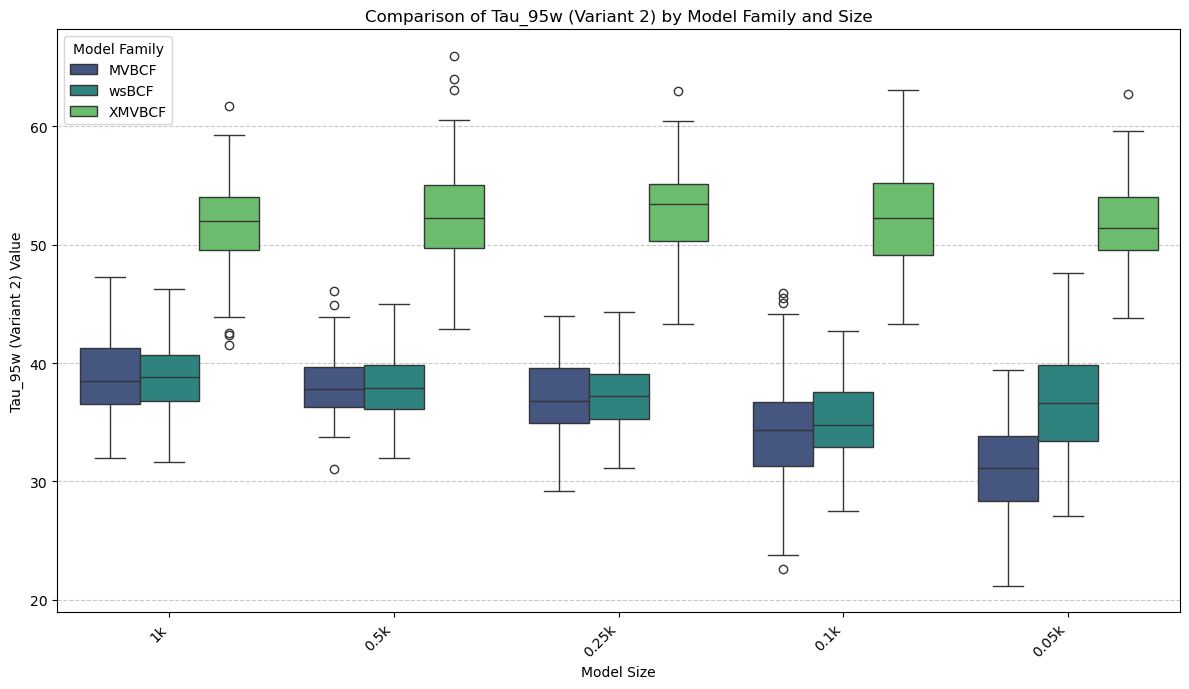

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    df_mvbcf = pd.read_csv("simulation_results_DGP3_original.csv")
    df_wsmvbcf = pd.read_csv("simulation_results_DGP3.csv")
    # Add wsBCF model, as per request, using the same CSV as XMVBCF.
    # Note: If wsBCF is truly a distinct model using this file, its column names
    # (e.g., 'wsbcf_1k_pehe1') should ideally be different from XMVBCF's ('mvbcf_1k_pehe1').
    # However, following the prompt literally, we'll assume its relevant data
    # shares the 'mvbcf_' prefix in this file, leading to identical results with XMVBCF.
    df_xmvbcf = pd.read_csv("XMVBCF_simulation_results_DGP3.csv") 
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
df_mvbcf['model_family'] = 'MVBCF'
df_xmvbcf['model_family'] = 'XMVBCF'
df_wsmvbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine all DataFrames
df_combined = pd.concat([df_mvbcf, df_xmvbcf, df_wsmvbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get MVBCF results
        mvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if mvbcf_col in df_mvbcf.columns:
            mean_mvbcf = df_mvbcf[mvbcf_col].mean()
            std_mvbcf = df_mvbcf[mvbcf_col].std()
            row_data["MVBCF"] = f"{mean_mvbcf:.3f} +/- {std_mvbcf:.3f}"
        else:
            row_data["MVBCF"] = "N/A"

        # Get XMVBCF results
        # XMVBCF uses columns also prefixed 'mvbcf_' in its specific file.
        xmvbcf_col = f"mvbcf_{model_size}_{base_name}"
        if xmvbcf_col in df_xmvbcf.columns:
            mean_xmvbcf = df_xmvbcf[xmvbcf_col].mean()
            std_xmvbcf = df_xmvbcf[xmvbcf_col].std()
            row_data["XMVBCF"] = f"{mean_xmvbcf:.3f} +/- {std_xmvbcf:.3f}"
        else:
            row_data["XMVBCF"] = "N/A"
            
        # Get wsBCF results
        # As per request, wsBCF uses the same CSV file as XMVBCF.
        # Assuming its relevant columns are also prefixed 'mvbcf_'.
        wsbcf_col = f"mvbcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsmvbcf.columns:
            mean_wsbcf = df_wsmvbcf[wsbcf_col].mean()
            std_wsbcf = df_wsmvbcf[wsbcf_col].std()
            row_data["wsMVBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsMVBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting
    plot_cols_prefix = "mvbcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    # Rename columns for melting: remove "mvbcf_" and the specific metric suffix
    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

In [ ]:
bcf_0.05k_mod1<-bcf(X2, Z, Y[,1], X_test = X2_test,
  Z_test = Z_test, propensity_test = p_test,
             propensity_train=p, num_mcmc=n_iter,  num_gfr = 0)
bcf_0.05k_pehe1<-sqrt(mean((Tau1_test-rowMeans(bcf_0.05k_mod1$tau_hat_test))^2))

bcf_0.05k_mod2<-bcf(X2, Z, Y[,2], X_test = X2_test,
  Z_test = Z_test, propensity_test = p_test,
             propensity_train=p, num_mcmc=n_iter,  num_gfr = 0)
bcf_0.05k_pehe2<-sqrt(mean((Tau2_test-rowMeans(bcf_0.05k_mod2$tau_hat_test))^2))

bcf_0.05k_tau_951<-mean(diag(apply(bcf_0.05k_mod1$tau_hat_test, 1, in_cred, Tau1_test, 0.95)))
bcf_0.05k_tau_952<-mean(diag(apply(bcf_0.05k_mod2$tau_hat_test, 1, in_cred, Tau2_test, 0.95)))

bcf_0.05k_tau_951w<-mean(apply(bcf_0.05k_mod1$tau_hat_test, 1, cred_width, 0.95))
bcf_0.05k_tau_952w<-mean(apply(bcf_0.05k_mod2$tau_hat_test, 1, cred_width, 0.95))